In [2]:
%pip install matplotlib seaborn pandas numpy textstat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# MedAESQA exploratory analysis (FaithfulMed)

**Author:** Arshiya Salehi  
**Goal:** Extract useful signals from **MedAESQA** for the FaithfulMed multi-agent pipeline (Extractor, Simplifier, Verifier, Refiner, Readability) and decide whether additional datasets from `data/README.md` are required.

**Project context (September milestone):**
- MedAESQA = **evaluation & Verifier calibration** (human accuracy + evidence-support labels, expert nuggets).
- **MTSamples + PLABA** = simplification core (clinical source docs + professional↔plain pairs).
- **MedQuAD / Synthea / MedlinePlus** = consumer tone, FHIR stress tests, RAG glossary.
- MedAESQA is **not** discharge-summary simplification — task shape is *consumer health Q&A with PubMed-grounded answers*.


In [3]:
from __future__ import annotations

import json
import re
import urllib.request
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import textstat

# Repo paths (works in Colab if you clone the repo and set ROOT)
try:
    ROOT = Path(__file__).resolve().parent.parent
except NameError:
    ROOT = Path.cwd()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
MEDAESQA_PATH = DATA_DIR / "medaesqa_v1.json"
METHODS_XLSX = DATA_DIR / "MedAESQA_methods_M1-M30.xlsx"
HF_URL = "https://huggingface.co/datasets/deepak8452/MedAESQA/resolve/main/medaesqa_v1.json"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)


In [4]:
def ensure_medaesqa(path: Path = MEDAESQA_PATH) -> Path:
    if path.exists():
        return path
    path.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading MedAESQA → {path}")
    urllib.request.urlretrieve(HF_URL, path)
    return path


def load_medaesqa(path: Path = MEDAESQA_PATH) -> list[dict]:
    path = ensure_medaesqa(path)
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def iter_sentences(answer_obj: dict) -> list[dict]:
    sents = answer_obj.get("answer_sentences") or []
    if isinstance(sents, dict):
        return list(sents.values())
    return list(sents)


def iter_citations(sentence: dict) -> list[dict]:
    cas = sentence.get("citation_assessment")
    if cas is None:
        return []
    if isinstance(cas, dict):
        return list(cas.values())
    return list(cas)


METHODS = [f"M{i}" for i in range(1, 31)]
CUI_RE = re.compile(r"\[C\d+\]")

data = load_medaesqa()
print(f"Loaded {len(data)} questions from {MEDAESQA_PATH.name}")
print("Top-level keys (first item):", list(data[0].keys()))


Loaded 40 questions from medaesqa_v1.json
Top-level keys (first item): ['question_id', 'question', 'question_frame', 'expert_curated_answer', 'machine_generated_answers', 'nuggets']


## 1. Schema & field naming

Documentation sometimes refers to `expert_curated_nuggets`; the released file uses **`nuggets`**. Confirm keys before wiring agents.


In [5]:
sample = data[0]
display_cols = {k: sample[k] for k in sample if k != "machine_generated_answers"}
pd.set_option("display.max_colwidth", 120)
pd.DataFrame([display_cols]).T.rename(columns={0: "example"})

m1 = sample["machine_generated_answers"]["M1"]
print("M1 keys:", list(m1.keys()))
sent = iter_sentences(m1)[0]
print("Sentence keys:", list(sent.keys()))
cites = iter_citations(sent)
if cites:
    print("Citation keys:", list(cites[0].keys()))
print("Question frame dimensions:", list(sample["question_frame"].keys()))
print("Sample nugget:", sample["nuggets"][0])


M1 keys: ['answer', 'is_answer_accurate', 'answer_sentences']
Sentence keys: ['answer_sentence_id', 'answer_sentence', 'answer_sentence_relevance', 'citation_assessment']
Citation keys: ['cited_pmid', 'evidence_support', 'evidence_relation']
Question frame dimensions: ['Focus', 'Type', 'Task', 'Subject matter (focus)', 'Body system', 'Specialty']
Sample nugget: Exists (treat naturally[C0027495], sleep apnea [C0037315])


## 2. Dataset scale & completeness


In [6]:
# --- flatten to tables for analysis ---
rows_q = []
rows_answers = []
rows_sentences = []
rows_citations = []
rows_nuggets = []

for q in data:
    qid = q["question_id"]
    frame = q.get("question_frame") or {}
    rows_q.append(
        {
            "question_id": qid,
            "question": q["question"],
            **{f"frame_{k}": v for k, v in frame.items()},
            "expert_answer_chars": len(q.get("expert_curated_answer") or ""),
            "n_nuggets": len(q.get("nuggets") or []),
        }
    )
    for n in q.get("nuggets") or []:
        rows_nuggets.append({"question_id": qid, "nugget": str(n), "has_cui": bool(CUI_RE.search(str(n)))})

    for method, obj in (q.get("machine_generated_answers") or {}).items():
        ans = obj.get("answer") or ""
        rows_answers.append(
            {
                "question_id": qid,
                "method": method,
                "answer_text": ans.strip(),
                "is_answer_accurate": obj.get("is_answer_accurate"),
                "answer_word_count": len(ans.split()),
                "answer_chars": len(ans),
                "n_sentences": len(iter_sentences(obj)),
            }
        )
        for s in iter_sentences(obj):
            rows_sentences.append(
                {
                    "question_id": qid,
                    "method": method,
                    "sentence_id": s.get("answer_sentence_id"),
                    "relevance": s.get("answer_sentence_relevance"),
                    "sentence_word_count": len((s.get("answer_sentence") or "").split()),
                    "citation_assessment_is_null": s.get("citation_assessment") is None,
                    "n_citations": len(iter_citations(s)),
                }
            )
            for c in iter_citations(s):
                rows_citations.append(
                    {
                        "question_id": qid,
                        "method": method,
                        "cited_pmid": c.get("cited_pmid"),
                        "evidence_relation": c.get("evidence_relation"),
                        "evidence_support_chars": len(str(c.get("evidence_support") or "")),
                        "evidence_support_empty": not bool(str(c.get("evidence_support") or "").strip()),
                    }
                )

df_q = pd.DataFrame(rows_q)
df_ans = pd.DataFrame(rows_answers)
df_sent = pd.DataFrame(rows_sentences)
df_cite = pd.DataFrame(rows_citations)
df_nug = pd.DataFrame(rows_nuggets)

summary = pd.Series(
    {
        "questions": len(df_q),
        "machine_answers (40×30)": len(df_ans),
        "expert_nuggets": len(df_nug),
        "answer_sentences": len(df_sent),
        "citation_assessment_rows": len(df_cite),
        "unique_pmids_cited": df_cite["cited_pmid"].nunique(dropna=True),
    }
)
print("Scale summary:")
display(summary.to_frame("count"))

# Method coverage
missing_methods = df_ans.groupby("question_id")["method"].nunique()
print("Methods per question — min/max:", missing_methods.min(), missing_methods.max())
print("Expected methods present for all questions:", set(METHODS).issubset(set(df_ans["method"])))


Scale summary:


,count
questions,40
machine_answers (40×30),1200
expert_nuggets,498
answer_sentences,5162
citation_assessment_rows,9611
unique_pmids_cited,2855


Methods per question — min/max: 30 30
Expected methods present for all questions: True


## 3. Duplicates


In [7]:
dup_qid = int(df_q["question_id"].duplicated().sum())
dup_qtext = int(df_q["question"].str.strip().str.lower().duplicated().sum())
exact_expert_dup = int(pd.Series([q["expert_curated_answer"].strip() for q in data]).duplicated().sum())

dup_within_q = int(
    df_ans.groupby("question_id")["answer_text"].apply(lambda s: len(s) - s.nunique()).sum()
)
text_reuse = int(df_ans["answer_text"].value_counts().gt(1).sum())

dup_report = pd.Series(
    {
        "duplicate question_id": dup_qid,
        "duplicate question text (case-insensitive)": dup_qtext,
        "duplicate expert answers (exact text)": exact_expert_dup,
        "extra duplicate machine answers within same question": dup_within_q,
        "distinct answer texts appearing more than once": text_reuse,
    }
)
display(dup_report.to_frame("value"))


,value
duplicate question_id,0
duplicate question text (case-insensitive),0
duplicate expert answers (exact text),0
extra duplicate machine answers within same question,25
distinct answer texts appearing more than once,20


## 4. Missing / null fields (data cleanliness)


In [8]:
# Top-level empties
top_missing = {}
for field in ["question_id", "question", "question_frame", "expert_curated_answer", "nuggets", "machine_generated_answers"]:
    top_missing[field] = sum(1 for q in data if not q.get(field))

# Answer-level
acc_missing = (df_ans["is_answer_accurate"].isna() | ~df_ans["is_answer_accurate"].isin(["yes", "no"])).sum()
null_cite_assessment = df_sent["citation_assessment_is_null"].sum()
empty_evidence = df_cite["evidence_support_empty"].sum()
null_relevance = df_sent["relevance"].isna().sum()
null_pmid = df_cite["cited_pmid"].isna().sum()

cleanliness = pd.DataFrame(
    {
        "metric": [
            "top-level missing fields (any question)",
            "non yes/no is_answer_accurate",
            "sentences with null citation_assessment",
            "sentences with null relevance label",
            "citation rows with empty evidence_support",
            "citation rows with null PMID",
            "nuggets without UMLS CUI marker",
        ],
        "count": [
            sum(top_missing.values()),
            int(acc_missing),
            int(null_cite_assessment),
            int(null_relevance),
            int(empty_evidence),
            int(null_pmid),
            int((~df_nug["has_cui"]).sum()),
        ],
        "pct_of_relevant": [
            None,
            acc_missing / len(df_ans) * 100,
            null_cite_assessment / len(df_sent) * 100,
            null_relevance / len(df_sent) * 100,
            empty_evidence / max(len(df_cite), 1) * 100,
            null_pmid / max(len(df_cite), 1) * 100,
            (~df_nug["has_cui"]).mean() * 100,
        ],
    }
)
display(cleanliness)

print("Top-level field gaps:", top_missing)


,metric,count,pct_of_relevant
0,top-level missing fields (any question),0,NaN
1,non yes/no is_answer_accurate,0,0.000000
2,sentences with null citation_assessment,1149,22.258814
3,sentences with null relevance label,244,4.726850
4,citation rows with empty evidence_support,1960,20.393299
5,citation rows with null PMID,0,0.000000
6,nuggets without UMLS CUI marker,0,0.000000


Top-level field gaps: {'question_id': 0, 'question': 0, 'question_frame': 0, 'expert_curated_answer': 0, 'nuggets': 0, 'machine_generated_answers': 0}


## 5. What the dataset mostly contains (distributions)


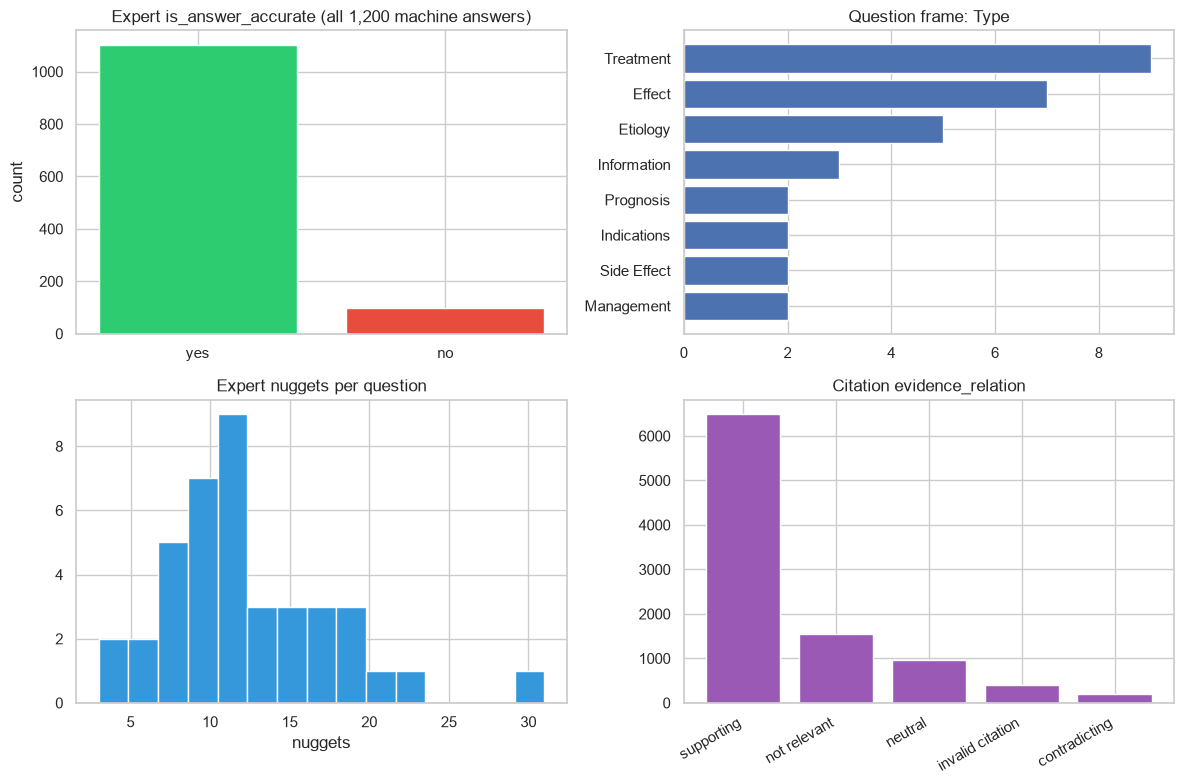

Sentence relevance distribution:


relevance
required         3958
unnecessary       698
NaN               244
borderline        243
inappropriate      19
Name: count, dtype: int64

Top nugget predicate stems:


nugget
[may] Cause       55
Is                55
Cause             27
Associated        27
Treat             25
Include           25
[may] Treat       19
Reduce            17
[may] Reduce      12
Help              11
increased risk    10
Symptom           10
Name: count, dtype: int64

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Human accuracy labels (Verifier calibration target)
acc_counts = df_ans["is_answer_accurate"].value_counts()
axes[0, 0].bar(acc_counts.index.astype(str), acc_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0, 0].set_title("Expert is_answer_accurate (all 1,200 machine answers)")
axes[0, 0].set_ylabel("count")

# Question framing
frame_type = df_q["frame_Type"].value_counts().head(8)
axes[0, 1].barh(frame_type.index[::-1], frame_type.values[::-1])
axes[0, 1].set_title("Question frame: Type")

# Nuggets per question
axes[1, 0].hist(df_q["n_nuggets"], bins=15, color="#3498db", edgecolor="white")
axes[1, 0].set_title("Expert nuggets per question")
axes[1, 0].set_xlabel("nuggets")

# Evidence relations
rel = df_cite["evidence_relation"].value_counts().head(6)
axes[1, 1].bar(rel.index.astype(str), rel.values, color="#9b59b6")
axes[1, 1].set_title("Citation evidence_relation")
plt.setp(axes[1, 1].get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Sentence relevance (granular faithfulness)
print("Sentence relevance distribution:")
display(df_sent["relevance"].value_counts(dropna=False))

# Nugget predicate stems
pred = df_nug["nugget"].str.split("(").str[0].str.strip().value_counts().head(12)
print("Top nugget predicate stems:")
display(pred)


## 6. Readability vs. FaithfulMed targets

FaithfulMed targets **≤8th-grade** patient-friendly text. MedAESQA answers are **consumer health Q&A** (often already lay-oriented) — use this as a sanity check, not as discharge-summary readability.


,expert_curated,machine_M1-M30
flesch_kincaid,11.79,15.54
smog,13.32,16.66
jargon_density,0.28,0.37
word_count,92.45,93.60
meets_8th_grade,0.08,0.02
pct_meets_8th_grade,7.50,1.83


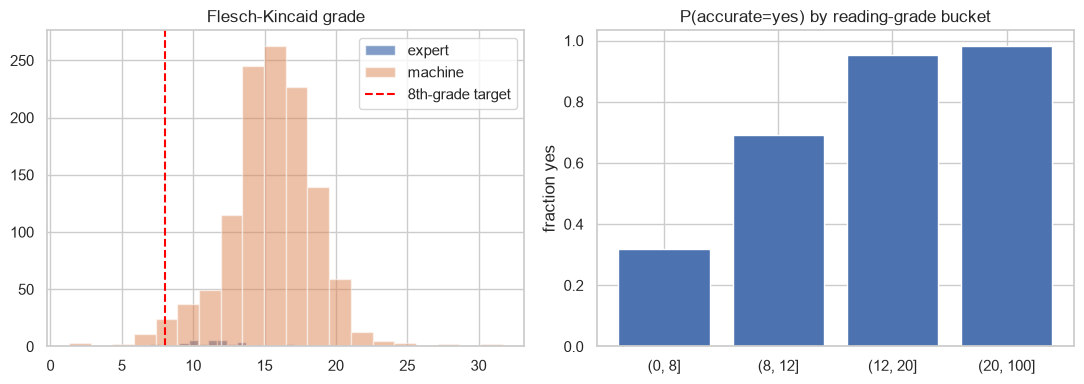

In [10]:
def readability_row(text: str) -> dict:
    text = text or ""
    words = max(textstat.lexicon_count(text, removepunct=True), 1)
    fk = textstat.flesch_kincaid_grade(text)
    return {
        "flesch_kincaid": fk,
        "smog": textstat.smog_index(text),
        "jargon_density": textstat.difficult_words(text) / words,
        "word_count": words,
        "meets_8th_grade": fk <= 8.0,
    }


expert_read = [readability_row(q["expert_curated_answer"]) for q in data]
df_expert_read = pd.DataFrame(expert_read)
df_machine_read = pd.DataFrame([readability_row(t) for t in df_ans["answer_text"]])

read_summary = pd.DataFrame(
    {
        "expert_curated": df_expert_read.mean(numeric_only=True),
        "machine_M1-M30": df_machine_read.mean(numeric_only=True),
    }
)
read_summary.loc["pct_meets_8th_grade"] = [
    df_expert_read["meets_8th_grade"].mean() * 100,
    df_machine_read["meets_8th_grade"].mean() * 100,
]
display(read_summary.round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df_expert_read["flesch_kincaid"], bins=20, alpha=0.7, label="expert")
ax[0].hist(df_machine_read["flesch_kincaid"], bins=20, alpha=0.5, label="machine")
ax[0].axvline(8, color="red", ls="--", label="8th-grade target")
ax[0].set_title("Flesch-Kincaid grade")
ax[0].legend()

acc_by_grade = df_ans.copy()
acc_by_grade["fk"] = df_machine_read["flesch_kincaid"].values
# accuracy rate by FK bucket
acc_by_grade["fk_bucket"] = pd.cut(acc_by_grade["fk"], bins=[0, 8, 12, 20, 100])
bucket = acc_by_grade.groupby("fk_bucket", observed=True)["is_answer_accurate"].apply(lambda s: (s == "yes").mean())
ax[1].bar([str(b) for b in bucket.index], bucket.values)
ax[1].set_title("P(accurate=yes) by reading-grade bucket")
ax[1].set_ylabel("fraction yes")
plt.tight_layout()
plt.show()


## 7. Verifier / Extractor utility preview

- **Verifier:** 1,200 labels (`yes`/`no`) + sentence-level relevance + evidence relations → calibrate LLM-as-judge (target κ ≥ 0.6).
- **Extractor:** 498 UMLS-tagged nuggets → gold atoms for fact coverage checks.
- **Not included:** plain-language rewrite pairs, clinical report source text, or FHIR documents.


In [11]:
# Per-method accuracy (M1–M30) — quality spread for Verifier
method_acc = df_ans.groupby("method")["is_answer_accurate"].apply(lambda s: (s == "yes").mean()).sort_values()
print("Accuracy rate by generation method (min → max):")
display(method_acc.to_frame("P_yes"))

# Class balance for binary Verifier training/calibration
print("Overall P(accurate=yes):", (df_ans["is_answer_accurate"] == "yes").mean())

# Nuggets per question vs machine accuracy spread
q_acc = df_ans.groupby("question_id")["is_answer_accurate"].apply(lambda s: (s == "yes").mean())
merged = df_q.set_index("question_id").join(q_acc.rename("p_accurate"))
display(merged[["n_nuggets", "p_accurate"]].describe())


Accuracy rate by generation method (min → max):


,P_yes
method,
M5,0.575
M15,0.650
M22,0.650
M23,0.750
M13,0.800
M7,0.825
M14,0.900
M21,0.900
M18,0.925


Overall P(accurate=yes): 0.9183333333333333


,n_nuggets,p_accurate
count,40.000000,40.000000
mean,12.450000,0.918333
std,5.472308,0.082327
min,3.000000,0.600000
25%,9.000000,0.866667
50%,11.500000,0.933333
75%,16.000000,0.966667
max,31.000000,1.000000


In [12]:
# Optional: M1–M30 generation pipeline metadata (if xlsx present in data/)
if METHODS_XLSX.exists():
    methods_df = pd.read_excel(METHODS_XLSX, sheet_name=None)
    print("Sheets:", list(methods_df.keys()))
    first_sheet = next(iter(methods_df.values()))
    display(first_sheet.head())
else:
    print(
        f"{METHODS_XLSX.name} not found locally. "
        "Add it under data/ (see data/README.md) to map each M1–M30 answer to retrieval/generation settings."
    )


Sheets: ['Sheet1']


,Method,Query Formulation and Expansion,Document Retrieval,Document Reranking,Answer Generation,Post-hoc Citations
0,M1,"Concatenation of question, topic, and narrative",Hybrid approach considering BM25 and Stella to retreive the top-20 relevant documents. The fusion hyperparameters we...,No,The question (with topic and narrative) and the relevant documents are given to the Llama-3.1-70B-Instruct to gener...,Each sentence of the generated answer is attributed to specific articles from the top 20 retrieved documents using ...
1,M2,Questions are used as queries. Query expansion using the GPT4o-mini to generate boolean queries.,Elasticsearch BM25 is used to retrieve 50 articles from PubMed. The GPT4o-mini is then prompted to extract snippets ...,"The GPT4o-mini reranks the extracted snippets based on their relevance to the question, and the top 20 snippets are ...",The question and the snippets are given to the GPT-4o to return an answer (with references). The LLM was provided 10...,No
2,M3,"Concatenation of question, topic, and narrative",Hybrid approach considering BM25 and Stella to retrieve the top-20 relevant documents. The fusion hyperparameters we...,No,The question (with topic and narrative) and the relevant documents are given to Llama-3.1-8B-Instruct to generate th...,Each sentence of the generated answer is attributed to specific articles from the top 20 retrieved documents using...
3,M4,"Concatenation of question, topic, and narrative",Hybrid approach considering BM25 and Stella to retrieve the top-20 relevant documents. The fusion hyperparameters w...,No,The question (with topic and narrative) and the relevant documents are given to the Llama-3.1-70B-Instruct to gener...,Each sentence of the generated answer is attributed to specific articles from the top 20 retrieved documents using ...
4,M5,Concatenation of question and narrative,"Uses Elasticsearch BM25 to retrieve the ten articles from PubMed. Additionally, the MeSH terms extracted from the qu...",The passages from Elasticsearch are subsequently re-ranked with a pointwise (monoT5) model.,The question and the top-3 re-ranked passages are given to the Mistral-7B-Instruct-v0.3 to return an answer (with r...,No


## 8. Strengths & limitations for FaithfulMed

### Strengths
| Signal | Why it matters |
|--------|----------------|
| **40×30 machine answers** with expert **`is_answer_accurate`** | Built-in faithful vs. unfaithful spread for Verifier calibration and leaderboard baselines |
| **498 expert nuggets w/ UMLS CUIs** | Gold atomic facts for Extractor evaluation (coverage / omission) |
| **Sentence-level relevance + PubMed evidence snippets** | Fine-grained evidence-support labels; aligns with “provably faithful” goal |
| **Documented M1–M30 pipelines** | Understand *why* some answers fail (retrieval vs. generation) |

### Limitations (gaps vs. project task)
| Gap | Impact | Mitigation (other datasets) |
|-----|--------|------------------------------|
| **Task mismatch** — Q&A not discharge summaries / lab reports | MedAESQA alone cannot evaluate simplification of **MTSamples/Synthea** clinical prose | Build ~50 curated baseline pairs; use MedAESQA only for **Verifier** metrics |
| **Small N=40 questions** | Stable eval, but high variance; **not trainable** | Do not fine-tune on this; freeze gold set early |
| **Class skew** (~92% `accurate=yes`) | Verifier may bias toward “yes”; stratify metrics | Report precision/recall; use sentence-level negative evidence |
| **~22% sentences lack `citation_assessment`** | Holes in evidence chain for those sentences | Treat as missing evidence, not faithful |
| **No plain-language rewrite gold** | Cannot train Simplifier/Readability directly | **PLABA** pairs + **MedlinePlus** RAG |
| **No long clinical documents** | Extractor not stress-tested on real report length | **MTSamples**, flattened **Synthea** FHIR |
| **Consumer-health tone** | Readability stats here may **overstate** pipeline success on jargon-heavy reports | Re-run readability on MTSamples outputs |

### Do you need other datasets?
**Yes — by design.** MedAESQA is the **evaluation backbone** only. For September EDA across the stack:

| Dataset | Still needed for |
|---------|------------------|
| **PLABA** | Simplifier gold (professional ↔ plain) |
| **MTSamples** | Source documents + jargon-heavy readability |
| **MedlinePlus glossary** | Simplifier RAG index |
| **Synthea** | FHIR flattening + synthetic care plans |
| **MedQuAD** | Optional consumer Q&A tone / retrieval eval |
| **MedQA / PubMedQA** | Optional; clinical reasoning — **low priority** per scope note |

**Recommendation:** Freeze `medaesqa_v1.json` + your hand-built MTSamples/PLABA eval slice; use this notebook’s cleanliness stats when wiring `eval_harness.py` (note JSON key **`nuggets`**, not `expert_curated_nuggets`).


## 9. Export summary tables (optional)

Writes CSV summaries next to the notebook for the team README / report.


In [13]:
OUT = ROOT / "notebooks"

for name, frame in [
    ("medaesqa_questions_summary.csv", df_q),
    ("medaesqa_answers_summary.csv", df_ans),
    ("medaesqa_cleanliness.csv", cleanliness),
]:
    path = OUT / name
    frame.to_csv(path, index=False)
    print("Wrote", path)


Wrote c:\Users\arsh\Desktop\break though tech program\Google-2A-faithfulmed-a-multi-agent-system-for-faithful-patient-friendly-medical-explanations\notebooks\medaesqa_questions_summary.csv
Wrote c:\Users\arsh\Desktop\break though tech program\Google-2A-faithfulmed-a-multi-agent-system-for-faithful-patient-friendly-medical-explanations\notebooks\medaesqa_answers_summary.csv
Wrote c:\Users\arsh\Desktop\break though tech program\Google-2A-faithfulmed-a-multi-agent-system-for-faithful-patient-friendly-medical-explanations\notebooks\medaesqa_cleanliness.csv
